<a href="https://colab.research.google.com/github/SAMCPA07/copias_collab_data-science/blob/collab_datascience/avance_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVANCE DE PROYECTO


In [1]:
pip install pandas

In [2]:
import pandas as pd

# ALMACENAMIENTO

In [4]:
df = pd.read_excel("avance_bueno.xlsx")

# Medidas de Cálculo

In [5]:
media = df['log_price'].mean()
mediana= df['log_price'].median()
moda = df['log_price'].mode()[0]
varianza = df['log_price'].var()

print(f"Media: {media}")
print(f"Mediana: {mediana}" )
print(f"Moda: {moda}")
print(f"Varianza: {varianza}")

Media: 4.7820180765009574
Mediana: 4.709530201312334
Moda: 5.010635294096256
Varianza: 0.5148399034977685


Checar campos vacios por variable

In [6]:
nulos = df.isnull().sum()
print(nulos)

id                            6
log_price                     5
property_type                 5
room_type                     6
amenities                     6
accommodates                  6
bathrooms                   206
bed_type                      6
cancellation_policy           6
cleaning_fee                  6
city                          6
description                   6
first_review              15870
host_has_profile_pic        194
host_identity_verified      194
host_response_rate        18305
host_since                  194
instant_bookable              6
last_review               15833
latitude                      6
longitude                     6
name                          6
neighbourhood              6878
number_of_reviews             6
review_scores_rating      16728
thumbnail_url              8222
zipcode                     991
bedrooms                     99
beds                        139
dtype: int64


# VERIFICAR FILAS O CAMPOS NULOS

In [7]:
# Retorna True si TODAS las celdas de la fila son nulas
filas_vacias_conteo = df.isnull().all(axis=1).sum()
print(f"Hay {filas_vacias_conteo} filas completamente vacías.")

Hay 5 filas completamente vacías.


In [8]:
# Retorna el numero de fila ue esta vacia
filas_vacias_metodo2 = df.isnull().all(axis=1)
print(filas_vacias_conteo)

5


In [9]:
# Retorna TODAS las filas vacias y su campo
filas_vacias_metodo3 = df.isnull().describe
print(filas_vacias_metodo3)

<bound method NDFrame.describe of           id  log_price  property_type  room_type  amenities  accommodates  \
0      False      False          False      False      False         False   
1      False      False          False      False      False         False   
2      False      False          False      False      False         False   
3      False      False          False      False      False         False   
4      False      False          False      False      False         False   
...      ...        ...            ...        ...        ...           ...   
74112  False      False          False      False      False         False   
74113  False      False          False      False      False         False   
74114  False      False          False      False      False         False   
74115  False      False          False      False      False         False   
74116  False      False          False      False      False         False   

       bathrooms  bed_type  c

In [10]:
# 1. Filas que no tienen ABSOLUTAMENTE NADA
total_vacias = df.isnull().all(axis=1).sum()

# 2. Filas a las que les falta AL MENOS UN dato (incluye las vacías)
total_incompletas = df.isnull().any(axis=1).sum()

# 3. Filas que tienen ALGUNOS datos pero no todos (La resta)
solo_parciales = total_incompletas - total_vacias

# 4. Filas COMPLETAMENTE llenas
filas_llenas_conteo = df.notnull().all(axis=1).sum()

print(f"Total de filas 100% vacías: {total_vacias}")
print(f"Total de filas con datos faltantes (parciales): {solo_parciales}")
print(f"Total de filas afectadas: {total_incompletas}")
print(f"Filas 100% completas: {filas_llenas_conteo}")

Total de filas 100% vacías: 5
Total de filas con datos faltantes (parciales): 35622
Total de filas afectadas: 35627
Filas 100% completas: 38490


# DEFINIR DF SIN DATOS NULOS


In [11]:
df_completo = df.notnull().all(axis=1).sum()
print(df_completo)

38490


In [12]:
filas_completas = df.notnull().all(axis=1)
print(filas_completas)

0        False
1         True
2         True
3        False
4        False
         ...  
74112    False
74113     True
74114     True
74115    False
74116     True
Length: 74117, dtype: bool


In [13]:
df_sin_nulos = df[filas_completas]
display(df_sin_nulos)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
1,6304928.0,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7.0,1.0,Real Bed,strict,1.0,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6.0,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019.0,3.0,3.0
2,7919400.0,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5.0,1.0,Real Bed,moderate,1.0,...,40.808110,-73.943756,The Garden Oasis,Harlem,10.0,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027.0,1.0,3.0
5,12422935.0,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2.0,1.0,Real Bed,strict,1.0,...,37.753164,-122.429526,Comfort Suite San Francisco,Noe Valley,3.0,100.0,https://a0.muscache.com/im/pictures/82509143-4...,94131.0,1.0,1.0
7,13971273.0,4.787492,Condominium,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Wheelchair...",2.0,1.0,Real Bed,moderate,1.0,...,34.046737,-118.260439,"Near LA Live, Staple's. Starbucks inside. OWN ...",Downtown,9.0,93.0,https://a0.muscache.com/im/pictures/61bd05d5-c...,90015.0,1.0,1.0
8,180792.0,4.787492,House,Private room,"{TV,""Cable TV"",""Wireless Internet"",""Pets live ...",2.0,1.0,Real Bed,moderate,1.0,...,37.781128,-122.501095,Cozy Garden Studio - Private Entry,Richmond District,159.0,99.0,https://a0.muscache.com/im/pictures/0ed6c128-7...,94121.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74108,7935934.0,4.110874,Villa,Shared room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",10.0,3.0,Real Bed,flexible,0.0,...,34.199671,-118.618070,UR SWEET HOME IN LA,West Hills,1.0,80.0,https://a0.muscache.com/im/pictures/27fea634-a...,91307.0,1.0,10.0
74109,11829011.0,5.135798,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",2.0,1.0,Real Bed,moderate,1.0,...,37.789989,-122.407384,WorldMark W'ndm Union Square Studio,Union Square,24.0,98.0,https://a0.muscache.com/im/pictures/9a99e2de-c...,94108.0,1.0,1.0
74113,13281809.0,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4.0,2.0,Real Bed,moderate,1.0,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16.0,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254.0,2.0,4.0
74114,18688039.0,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5.0,1.0,Real Bed,moderate,1.0,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43.0,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0


In [14]:
df_sin_nulos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38490 entries, 1 to 74116
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      38490 non-null  float64       
 1   log_price               38490 non-null  float64       
 2   property_type           38490 non-null  object        
 3   room_type               38490 non-null  object        
 4   amenities               38490 non-null  object        
 5   accommodates            38490 non-null  float64       
 6   bathrooms               38490 non-null  float64       
 7   bed_type                38490 non-null  object        
 8   cancellation_policy     38490 non-null  object        
 9   cleaning_fee            38490 non-null  float64       
 10  city                    38490 non-null  object        
 11  description             38490 non-null  object        
 12  first_review            38490 non-null  datetime64[

# MEDIDAS DESCRIPTIVAS DE LAS VARIABLES

In [15]:
media_log_price = df_sin_nulos['log_price'].mean()
mediana_log_price= df_sin_nulos['log_price'].median()
moda_log_price = df_sin_nulos['log_price'].mode()[0]
varianza_log_price = df_sin_nulos['log_price'].var()

print(f"Media de log price: {media_log_price}")
print(f"Mediana log price: {mediana_log_price}" )
print(f"Moda log price: {moda_log_price}")
print(f"Varianza log price: {varianza_log_price}")

Media de log price: 4.745706905395279
Mediana log price: 4.700480365792417
Moda log price: 5.010635294096256
Varianza log price: 0.43297139405822405


PROPERTY TYPE

In [16]:
moda_property_type = df_sin_nulos['property_type'].mode()[0]
print(f"Moda de Property Type: {moda_property_type}")

Moda de Property Type: Apartment


ROOM TYPE

In [17]:
moda_room_type = df_sin_nulos['room_type'].mode()[0]
print(f"Moda de Room Type: {moda_room_type}")

Moda de Room Type: Entire home/apt


AMENITIES

In [18]:
moda_amenities = df_sin_nulos['amenities'].mode()[0]
print(f"Moda de Amenities: {moda_amenities}")

Moda de Amenities: {}


ACCOMMODATES

In [19]:
media_accommodates = df_sin_nulos['accommodates'].mean()
mediana_accommodates= df_sin_nulos['accommodates'].median()
moda_accommodates = df_sin_nulos['accommodates'].mode()[0]
varianza_accommodates = df_sin_nulos['accommodates'].var()

print(f"Media de Accommodates: {media_accommodates}")
print(f"Mediana de Accommodates: {mediana_accommodates}" )
print(f"Moda de Accommodates: {moda_accommodates}")
print(f"Varianza de Accommodates: {varianza_accommodates}")

Media de Accommodates: 3.2340088334632373
Mediana de Accommodates: 2.0
Moda de Accommodates: 2.0
Varianza de Accommodates: 4.5706898707929025


BATHROOMS

In [20]:
media_bathrooms = df_sin_nulos['bathrooms'].mean()
mediana_bathrooms= df_sin_nulos['bathrooms'].median()
moda_bathrooms = df_sin_nulos['bathrooms'].mode()[0]
varianza_bath = df_sin_nulos['bathrooms'].var()

print(f"Media de Bathrooms: {media_bathrooms}")
print(f"Mediana de Bathrooms: {mediana_bathrooms}")
print(f"Moda de Bathrooms: {moda_bathrooms}")
print(f"Varianza de Bathrooms: {varianza_bath}")

Media de Bathrooms: 1.2152637048584047
Mediana de Bathrooms: 1.0
Moda de Bathrooms: 1.0
Varianza de Bathrooms: 0.3040656440383178


BED TYPE

In [21]:
moda_bed_type = df_sin_nulos['bed_type'].mode()[0]
print(f"Moda de Bed Type: {moda_bed_type}")

Moda de Bed Type: Real Bed


CANCELLATION POLICY

In [22]:
moda_cancellation_policy = df_sin_nulos['cancellation_policy'].mode()[0]
print(f"Moda de Cancellation Policy: {moda_cancellation_policy}")

Moda de Cancellation Policy: strict


CLEANING FEE

In [23]:
moda_cleaning_fee = df_sin_nulos['cleaning_fee'].mode()[0]
print(f"Moda de Cleaning Fee: {moda_cleaning_fee}")

Moda de Cleaning Fee: 1.0


CITY

In [24]:
moda_city = df_sin_nulos['city'].mode()[0]
print(f"Moda de City: {moda_city}")

Moda de City: NYC


DESCRIPTION

In [25]:
moda_description = df_sin_nulos['description'].mode()[0]

print(f"Moda de Description: {moda_description}")

Moda de Description: Private room in the heart of Little Italy with FREE PARKING :) You will have your own personal door code and may arrive at ANY time you would like and as late as you wish. You can store your luggage in the closet before check-in and after check-out times :) Price adapts to demand, my rates change constantly - every night is different! Put your dates in the calendar, with the number of guests, and what you see is what you'll pay :) The neighborhood is extremely safe even at night :) Restaurants and bars are right round the corner, both upscale and casual. This room is 6 minutes away by car or uber to Chicago's famous Willis (Sears) tower. Uber costs about $7. If you are arriving by car, I am providing free resident parking passes for anywhere in the area. (Yes, that means you can drive a few blocks and still park anywhere you want!) The room will be solely yours for the time you'll stay in the Windy City. Shall you have any concerns or need any tips from the local, 

FIRST REVIEW

In [26]:
media_first_review = df_sin_nulos['first_review'].mean()
mediana_first_review= df_sin_nulos['first_review'].median()
moda_first_review = df_sin_nulos['first_review'].mode()[0]

print(f"Media de First Review: {media_first_review}")
print(f"Mediana de First Review: {mediana_first_review}" )
print(f"Moda de First Review: {moda_first_review}")

Media de First Review: 2016-01-30 08:54:48.542478592
Mediana de First Review: 2016-06-25 00:00:00
Moda de First Review: 2017-01-01 00:00:00


HOST HAS PROFILE PIC

In [27]:
moda_host_has_profile_pic = df_sin_nulos['host_has_profile_pic'].mode()[0]
print(f"Moda de Host Has Profile Pic: {moda_host_has_profile_pic}")

Moda de Host Has Profile Pic: t


HOST IDENTITY VERIFIED

In [28]:
moda_host_identity_verified = df_sin_nulos['host_identity_verified'].mode()[0]
print(f"Moda de Host Identity Verified: {moda_host_has_profile_pic}")

Moda de Host Identity Verified: t


HOST RESPONSE RATE

In [29]:
media_host_response_rate = df_sin_nulos['host_response_rate'].mean()
mediana_host_response_rate= df_sin_nulos['host_response_rate'].median()
moda_host_response_rate = df_sin_nulos['host_response_rate'].mode()[0]
varianza_host_response_rate = df_sin_nulos['host_response_rate'].var()

print(f"Media de Host Response Rate: {media_host_response_rate}")
print(f"Mediana de Host Response Rate: {mediana_host_response_rate}" )
print(f"Moda de Host Response Rate: {moda_host_response_rate}")
print(f"Varianza de Host Response Rate: {varianza_host_response_rate}")

Media de Host Response Rate: 0.961437516237984
Mediana de Host Response Rate: 1.0
Moda de Host Response Rate: 1.0
Varianza de Host Response Rate: 0.014372723693165147


HOST SINCE

In [30]:
moda_host_since = df_sin_nulos['host_since'].mode()[0]
print(f"Moda de Host Since: {moda_host_since}")

Moda de Host Since: 2014-02-14 00:00:00


INSTANT BOOKEABLE

In [31]:
moda_instant_bookable = df_sin_nulos['instant_bookable'].mode()[0]
print(f"Moda de Instant Bookable: {moda_instant_bookable}")

Moda de Instant Bookable: f


LAST REVIEW

In [32]:
media_last_review = df_sin_nulos['last_review'].mean()
mediana_last_review= df_sin_nulos['last_review'].median()
moda_last_review = df_sin_nulos['last_review'].mode()[0]

print(f"Media de Last Review: {media_last_review}")
print(f"Mediana de Last Review: {mediana_last_review}" )
print(f"Moda de Last Review: {moda_last_review}")

Media de Last Review: 2017-06-01 02:38:44.427123712
Mediana de Last Review: 2017-07-30 00:00:00
Moda de Last Review: 2017-09-24 00:00:00


LATITUDE

In [33]:
media_latitude = df_sin_nulos['latitude'].mean()
mediana_latitude= df_sin_nulos['latitude'].median()
moda_latitude = df_sin_nulos['latitude'].mode()[0]
varianza_latitude = df_sin_nulos['latitude'].var()

print(f"Media de Latitude: {media_latitude}")
print(f"Mediana de Latitude: {mediana_latitude}")
print(f"Moda de Latitude: {moda_latitude}")
print(f"Varianza de Latitude: {varianza_latitude}")

Media de Latitude: 38.75923447024541
Mediana de Latitude: 40.682550089374814
Moda de Latitude: 33.70583529438538
Varianza de Latitude: 9.046028928254012


LONGITUDE

In [34]:
media_longitude = df_sin_nulos['longitude'].mean()
mediana_longitude= df_sin_nulos['longitude'].median()
moda_longitude = df_sin_nulos['longitude'].mode()[0]
varianza_longitude = df_sin_nulos['longitude'].var()

print(f"Media de Longitude: {media_longitude}")
print(f"Mediana de Longitude: {mediana_longitude}")
print(f"Moda de Longitude: {moda_longitude}")
print(f"Varianza de Longitude: {varianza_longitude}")

Media de Longitude: -90.89421262018595
Mediana de Longitude: -74.00174430438226
Moda de Longitude: -122.51149998987214
Varianza de Longitude: 459.9565695161584


NAME

In [35]:
moda_name = df_sin_nulos['name'].mode()[0]
print(f"Moda de Name: {moda_name}")

Moda de Name: Bunk bed in the Treat Street Clubhouse


NEIGHBOURHOOD

In [36]:
moda_neighbourhood = df_sin_nulos['neighbourhood'].mode()[0]
print(f"Moda de Neighbourhood: {moda_neighbourhood}")

Moda de Neighbourhood: Williamsburg


NUMBER OF REVIEWS

In [37]:
media_number_of_reviews = df_sin_nulos['number_of_reviews'].mean()
madiana_number_of_reviews= df_sin_nulos['number_of_reviews'].median()
moda_number_of_reviews = df_sin_nulos['number_of_reviews'].mode()[0]

print(f"Media de Number of Reviews: {media_number_of_reviews}")
print(f"Mediana de Number of Reviews: {madiana_number_of_reviews}" )
print(f"Moda de Number of Reviews: {moda_number_of_reviews}")

Media de Number of Reviews: 32.96604312808522
Mediana de Number of Reviews: 16.0
Moda de Number of Reviews: 1.0


THUMBNAIL URL

In [38]:
moda_thumbnail_url = df_sin_nulos['thumbnail_url'].mode()[0]
print(f"Moda de Thumbnail URL: {moda_thumbnail_url}")

Moda de Thumbnail URL: https://a0.muscache.com/im/pictures/104667326/a7a2b145_original.jpg?aki_policy=small


ZIP CODE

In [39]:
mediana_zipcode = df_sin_nulos['zipcode'].median()
moda_zipcode = df_sin_nulos['zipcode'].mode()[0]

print(f"Mediana de Zipcode: {mediana_zipcode}")
print(f"Moda de Zipcode: {moda_zipcode}")

Mediana de Zipcode: 11369.0
Moda de Zipcode: 11211.0


BEDROOMS

In [40]:
media_bedrooms = df_sin_nulos['bedrooms'].mean()
mediana_bedrooms= df_sin_nulos['bedrooms'].median()
moda_bedrooms = df_sin_nulos['bedrooms'].mode()[0]
varianza_bedrooms = df_sin_nulos['bedrooms'].var()

print(f"Media de Bedrooms: {media_bedrooms}")
print(f"Mediana de Bedrooms: {mediana_bedrooms}")
print(f"Moda de Bedrooms: {moda_bedrooms}")
print(f"Varianza de Bedrooms: {varianza_bedrooms}")

Media de Bedrooms: 1.2524551831644584
Mediana de Bedrooms: 1.0
Moda de Bedrooms: 1.0
Varianza de Bedrooms: 0.6998854993685298


BEDS

In [41]:
media_beds = df_sin_nulos['beds'].mean()
mediana_beds= df_sin_nulos['beds'].median()
moda_beds = df_sin_nulos['beds'].mode()[0]
varianza_beds = df_sin_nulos['beds'].var()

print(f"Media de Beds: {media_beds}")
print(f"Mediana de Beds: {mediana_beds}")
print(f"Moda de Beds: {moda_beds}")
print(f"Varianza de Beds: {varianza_beds}")

Media de Beds: 1.7594180306573135
Mediana de Beds: 1.0
Moda de Beds: 1.0
Varianza de Beds: 1.6590769041515943


# MATRIZ DE CORRELACIÓN CON VALORES

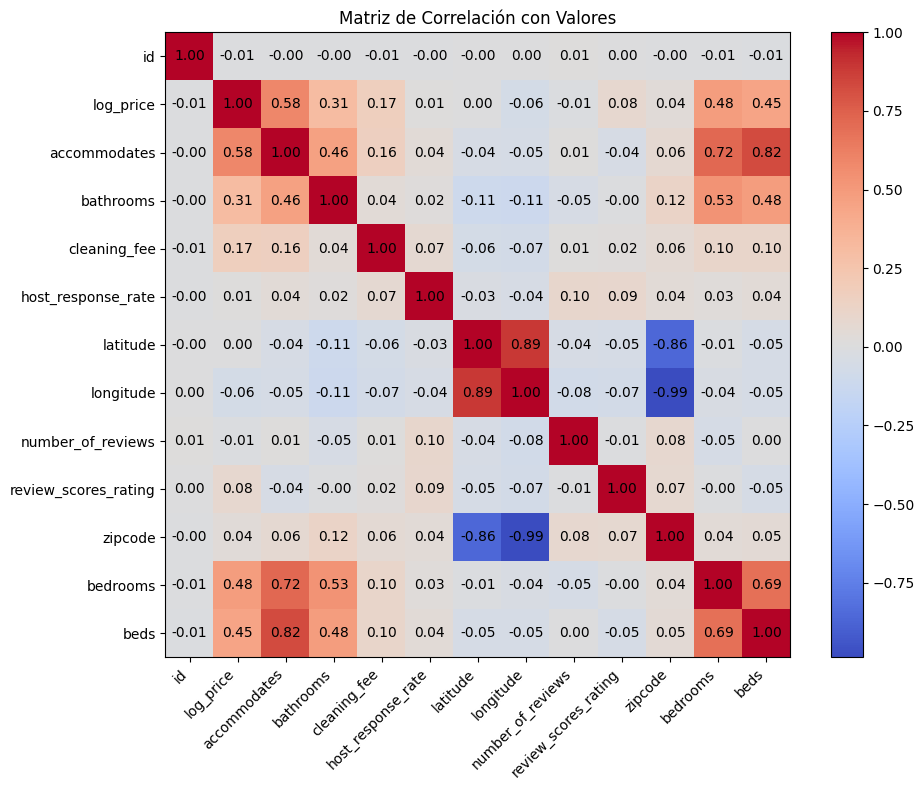

In [42]:
# se identifican las variables que podrían influir en el precio de la vivienda
import matplotlib.pyplot as plt
import numpy as np

# Tu matriz
matrix = df_sin_nulos.corr(method='pearson', min_periods=1, numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='coolwarm')

# Añadir etiquetas a los ejes
ax.set_xticks(np.arange(len(matrix.columns)))
ax.set_yticks(np.arange(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(matrix.columns)

# --- Bucle para añadir los VALORES ---
for i in range(len(matrix.columns)):
    for j in range(len(matrix.columns)):
        # matrix.iloc[i, j] obtiene el valor de la celda
        text = ax.text(j, i, f'{matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black")

ax.set_title("Matriz de Correlación con Valores")
fig.colorbar(im)
plt.tight_layout()
plt.show()

# VISUALIZACIÓN DE DATOS

SE IMPORTA LA LIBRERÍA MATPLOT PARA GENERAR LO PEDIDO

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

HISTOGRAMA

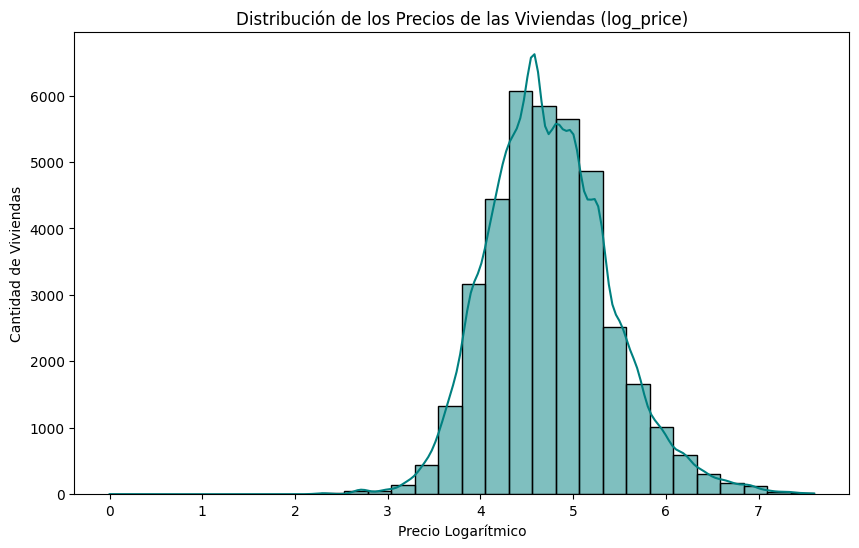

In [44]:
plt.figure(figsize=(10, 6))

# Dibujamos el histograma de la variable objetivo (log_price)
sns.histplot(data=df_sin_nulos, x='log_price', bins=30, kde=True, color='teal')

plt.title('Distribución de los Precios de las Viviendas (log_price)')
plt.xlabel('Precio Logarítmico')
plt.ylabel('Cantidad de Viviendas')

plt.show()

BOXPLOT DEL DATA FRAME

/tmp/ipykernel_19695/3031558009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sin_nulos, x='room_type', y='log_price', palette='Set2')


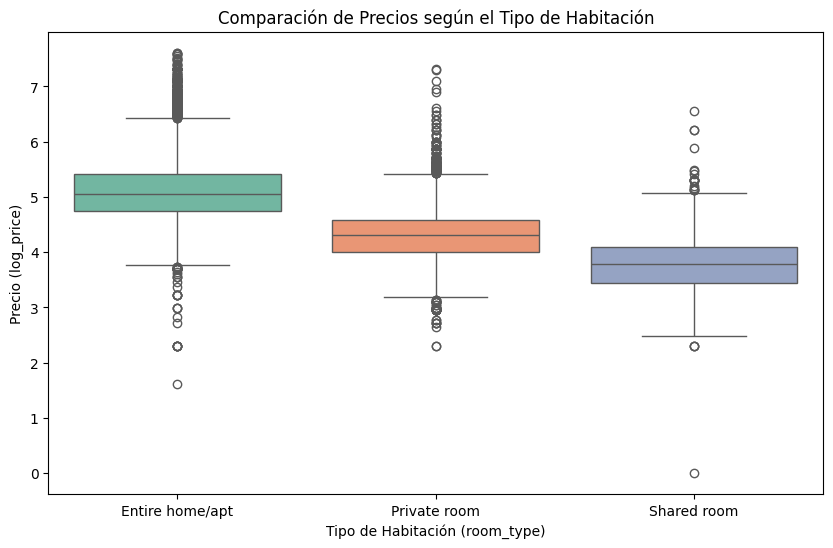

In [45]:
plt.figure(figsize=(10, 6))

# Dibujamos cajas que comparan una categoría de texto contra un número
sns.boxplot(data=df_sin_nulos, x='room_type', y='log_price', palette='Set2')

plt.title('Comparación de Precios según el Tipo de Habitación')
plt.xlabel('Tipo de Habitación (room_type)')
plt.ylabel('Precio (log_price)')

plt.show()

/tmp/ipykernel_19695/170601431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sin_nulos, x='cancellation_policy', y='log_price', palette='Pastel1')


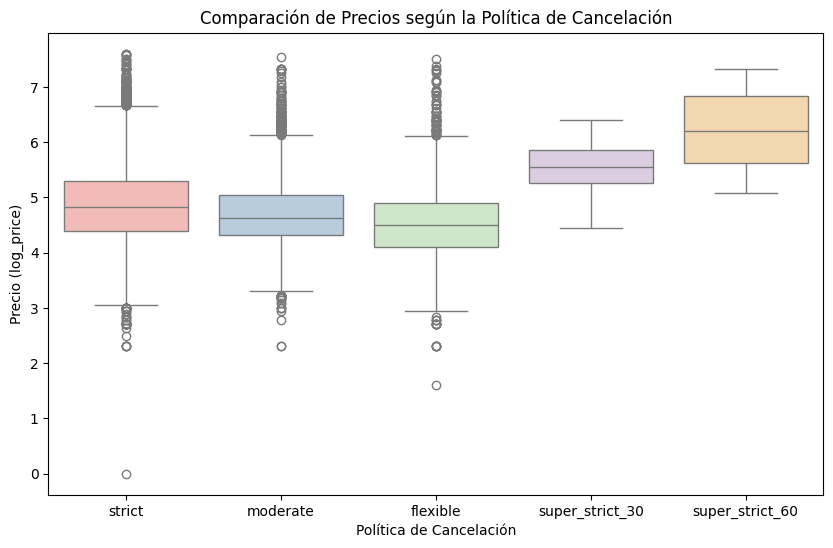

In [46]:
plt.figure(figsize=(10, 6))

# 'room_type' por 'cancellation_policy'
sns.boxplot(data=df_sin_nulos, x='cancellation_policy', y='log_price', palette='Pastel1')

plt.title('Comparación de Precios según la Política de Cancelación')
plt.xlabel('Política de Cancelación')
plt.ylabel('Precio (log_price)')

plt.show()

SCATTER PLOT

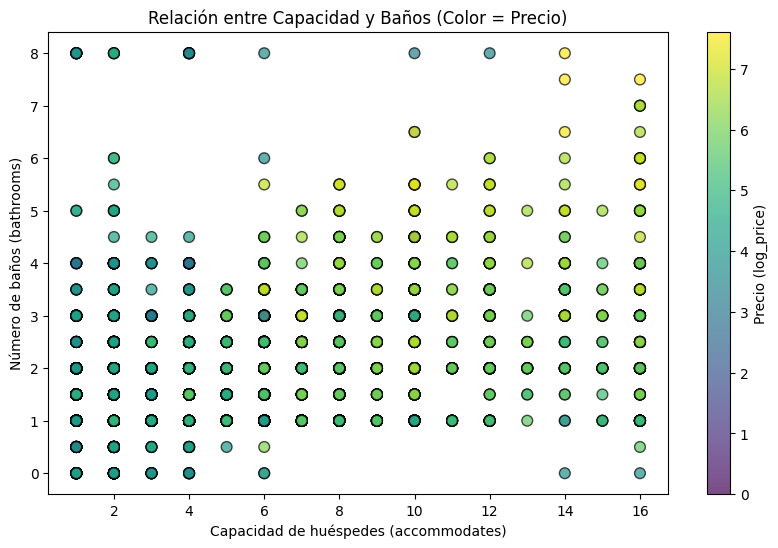

In [47]:
plt.figure(figsize=(10, 6))

# Eje X = Capacidad, Eje Y = Baños, Color (c) = Precio
grafico_3d = plt.scatter(df_sin_nulos['accommodates'],
                         df_sin_nulos['bathrooms'],
                         c=df_sin_nulos['log_price'],
                         cmap='viridis',
                         edgecolor='black',
                         s=60,
                         alpha=0.7)

plt.title('Relación entre Capacidad y Baños (Color = Precio)')
plt.xlabel('Capacidad de huéspedes (accommodates)')
plt.ylabel('Número de baños (bathrooms)')

# Agregamos la barra de colores a la derecha
plt.colorbar(grafico_3d, label='Precio (log_price)')

plt.show()

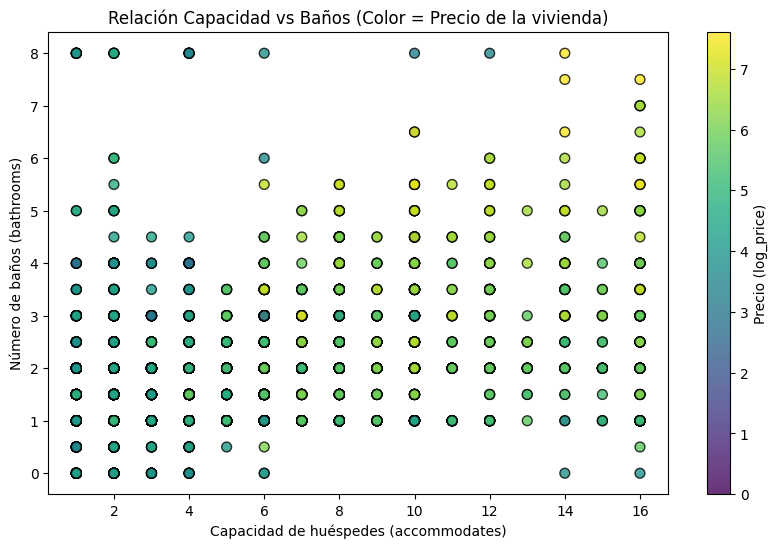

In [57]:
plt.figure(figsize=(10, 6))

# 1. Creamos el scatter plot y lo guardamos en una variable llamada 'grafico'
grafico = plt.scatter(df_sin_nulos['accommodates'], # Eje X
                      df_sin_nulos['bathrooms'],    # Eje Y
                      c=df_sin_nulos['log_price'],  # El Color será dictado por el precio
                      cmap='viridis',               # Paleta de colores (de morado a amarillo)
                      edgecolor='black',            # Borde negro para que resalte
                      s=50,                         # Tamaño de las bolitas
                      alpha=0.8)                    # Un poco de transparencia

# 2. Etiquetas
plt.xlabel('Capacidad de huéspedes (accommodates)')
plt.ylabel('Número de baños (bathrooms)')
plt.title('Relación Capacidad vs Baños (Color = Precio de la vivienda)')

# 3. La barra lateral de colores (colorbar)
# Le pasamos la variable 'grafico' para que sepa qué colores está leyendo
plt.colorbar(grafico, label='Precio (log_price)')

plt.show()

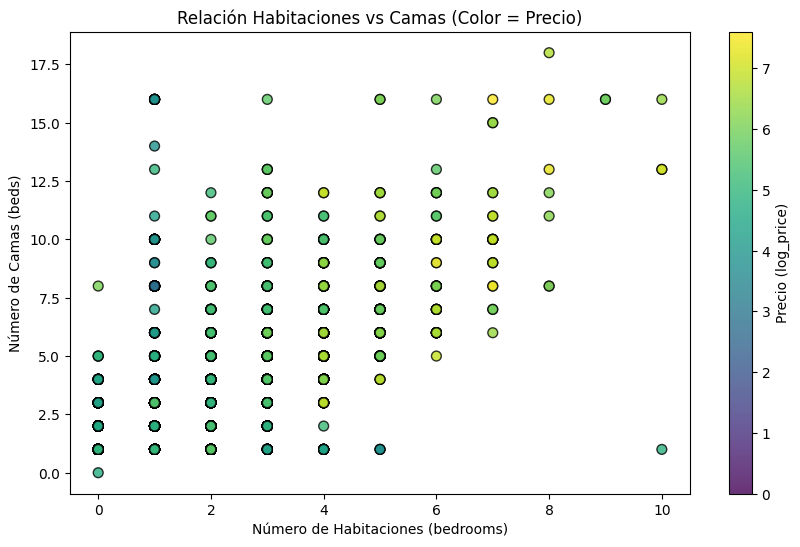

In [58]:
plt.figure(figsize=(10, 6))

grafico = plt.scatter(df_sin_nulos['bedrooms'], # Eje X: Habitaciones
                      df_sin_nulos['beds'],     # Eje Y: Camas
                      c=df_sin_nulos['log_price'], # Color: Precio
                      cmap='viridis',
                      edgecolor='black',
                      s=50,
                      alpha=0.8)

plt.xlabel('Número de Habitaciones (bedrooms)')
plt.ylabel('Número de Camas (beds)')
plt.title('Relación Habitaciones vs Camas (Color = Precio)')
plt.colorbar(grafico, label='Precio (log_price)')

plt.show()

# CREAMOS Y ENTRENAMOS EL MODELO PARA LUEGO LA PREDICCION

In [ ]:
pip install scikit-learn

In [48]:
from sklearn.linear_model import LinearRegression
x_df = df_sin_nulos[['accommodates', 'bathrooms', 'bedrooms', 'beds']]
y_df = df_sin_nulos['log_price']

modelo_df = LinearRegression()
modelo_df.fit(x_df, y_df)

datos_entrada = [[5, 3, 3, 3]]
predicciones_df = modelo_df.predict(datos_entrada)

print(f"Precio: {predicciones_df[0]:.2f}")

Precio: 5.24


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt

VISUALIZAR PREDICCION (ESTA FUE NAMAS UNA PRUEBA, LOS DEMAS ESTAN ABAJO, EN LA SIGUIENTE SECCION

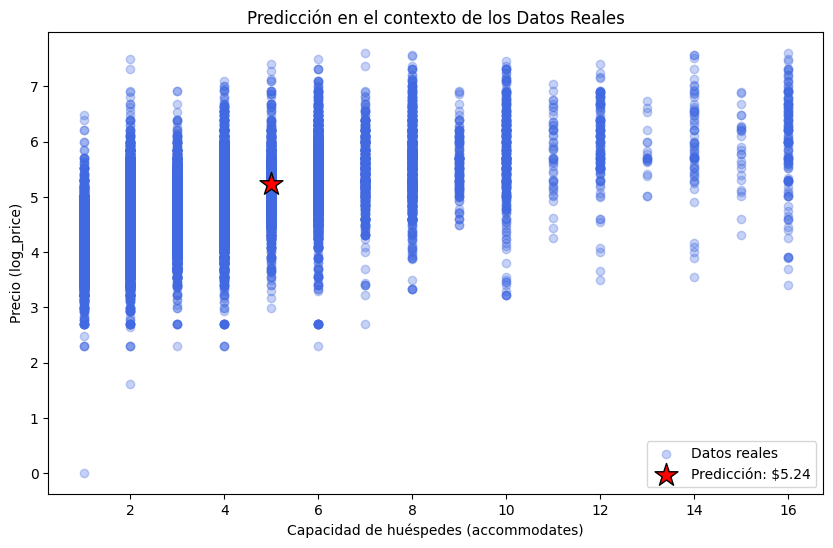

In [53]:
# 1. Extraemos el valor numérico de la predicción
valor_predicho = predicciones_df[0]

# Extraemos el valor de 'accommodates'
valor_accommodates = datos_entrada[0][0]

plt.figure(figsize=(10, 6))

# 2. Dibujamos la nube de puntos de los datos reales (usamos 'accommodates' para el eje X)
plt.scatter(df_sin_nulos['accommodates'], df_sin_nulos['log_price'],
            alpha=0.3, color='royalblue', label='Datos reales')

# 3. Dibujamos predicción dinámica.
# Usamos la variable
plt.scatter(valor_accommodates, valor_predicho,
            color='red', s=300, marker='*', edgecolor='black',
            label=f'Predicción: ${valor_predicho:.2f}')

plt.title('Predicción en el contexto de los Datos Reales')
plt.xlabel('Capacidad de huéspedes (accommodates)')
plt.ylabel('Precio (log_price)')
plt.legend()
plt.show()

# VISUALIZAR PREDICCION EN UNA SOLA IMAGEN (CON CICLO FOR) y REPRESENTACION

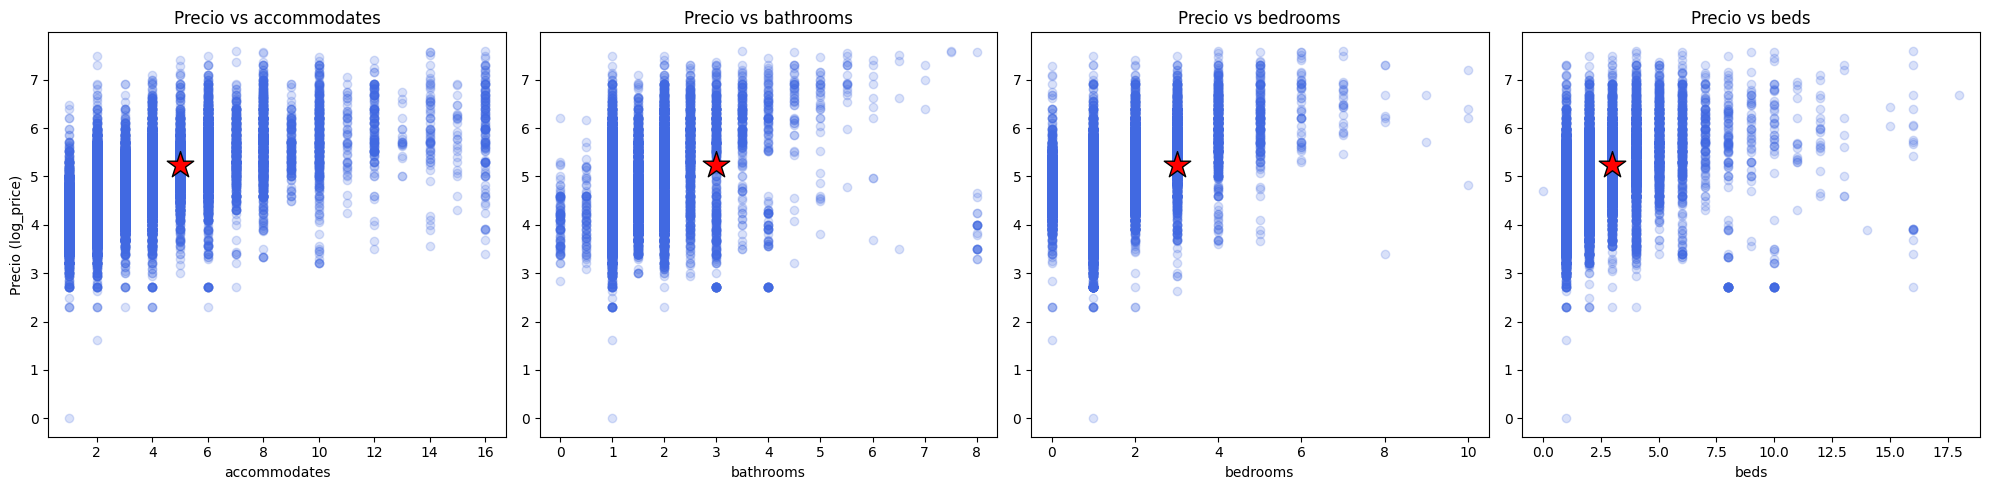

In [54]:
# predicción actual (suponiendo que ya corriste el predict antes)
valor_predicho = predicciones_df[0]

# 4 valores de entrada: [accommodates, bathrooms, bedrooms, beds]
entradas = datos_entrada[0]
nombres_columnas = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

# Creamos una figura ancha con 4 gráficos en fila (1 fila, 4 columnas)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Hacemos un ciclo para dibujar cada uno de los 4 gráficos automáticamente
for i in range(4):
    columna = nombres_columnas[i]
    valor_x = entradas[i]

    # 1. Dibujamos los datos reales (los puntitos azules)
    axes[i].scatter(df_sin_nulos[columna], df_sin_nulos['log_price'],
                    alpha=0.2, color='royalblue')

    # 2. Dibujamos la predicción en cada gráfico (la estrella roja)
    axes[i].scatter(valor_x, valor_predicho,
                    color='red', s=400, marker='*', edgecolor='black', zorder=5)

    # Títulos y etiquetas
    axes[i].set_title(f'Precio vs {columna}')
    axes[i].set_xlabel(columna)
    if i == 0:
        axes[i].set_ylabel('Precio (log_price)')

# Ajustamos el espacio para que no se amontonen y mostramos
plt.tight_layout()
plt.show()

# BUCLE FOR PARA TODAS LAS VARIABLES (PRUEBA Xd) puro relleno (nada importante btw)

In [ ]:
# Iteramos sobre las columnas de tu DataFrame sin nulos
for columna in df_sin_nulos.columns:
    if columna == 'id':
        continue

    print(f"--- Estadísticas para: {columna} ---")

    # Manejo de la moda (aplica tanto para números como para texto)
    if not df_sin_nulos[columna].dropna().empty: # se valida si no esta vacia la columna a evaluar
        moda = df_sin_nulos[columna].mode()[0]
    else:
        moda = "Vacío/NaN" # por si esta vacio

    # Verificamos si la columna es numérica para media, mediana y varianza
    if pd.api.types.is_numeric_dtype(df_sin_nulos[columna]): # se valida si es numerico o no
        media = df_sin_nulos[columna].mean() # media de la columna
        mediana = df_sin_nulos[columna].median() # mediana de la columna
        varianza = df_sin_nulos[columna].var() # varianza de la columna

        # se imprimen
        print(f"Media:    {media:.4f}")
        print(f"Mediana:  {mediana:.4f}")
        print(f"Varianza: {varianza:.4f}")
        print(f"Moda:     {moda}\n")

    else:
        # Si entra aquí, es texto (string), booleano o fecha
        print("Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)")
        print(f"Moda (valor más frecuente): {moda}\n")

--- Estadísticas para: log_price ---
Media:    4.7457
Mediana:  4.7005
Varianza: 0.4330
Moda:     5.010635294096256

--- Estadísticas para: property_type ---
Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)
Moda (valor más frecuente): Apartment

--- Estadísticas para: room_type ---
Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)
Moda (valor más frecuente): Entire home/apt

--- Estadísticas para: amenities ---
Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)
Moda (valor más frecuente): {}

--- Estadísticas para: accommodates ---
Media:    3.2340
Mediana:  2.0000
Varianza: 4.5707
Moda:     2.0

--- Estadísticas para: bathrooms ---
Media:    1.2153
Mediana:  1.0000
Varianza: 0.3041
Moda:     1.0

--- Estadísticas para: bed_type ---
Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)
Moda (valor más frecuente): Real Bed

--- Estadísticas para: cancellation_policy ---
Tipo de dato: Texto/Categórico (Se omiten cálculos matemáticos)
Mo